In [13]:
# Imports

import torch
import torch.nn as nn
import numpy as np
import ta
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
%matplotlib inline

In [14]:
# Load data

df = yf.download("QQQ", start="2000-01-01")

# Flatten Headers
df.columns = df.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [15]:
# Features

# Essentially asking, is tomorrow closing vlaue going to be higher?
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# Create features
# Change in volume
df["Volume_Change"] = df["Volume"].pct_change() * 100

# Exppnetial Moving Averages
df["EMA_9"] = ta.trend.EMAIndicator(df["Close"].squeeze(), window=9).ema_indicator()
df["EMA_21"] = ta.trend.EMAIndicator(df["Close"].squeeze(), window=21).ema_indicator()
df["EMA_50"] = ta.trend.EMAIndicator(df["Close"].squeeze(), window=50).ema_indicator()
df["EMA_200"] = ta.trend.EMAIndicator(df["Close"].squeeze(), window=200).ema_indicator()

# Automatically removes NaN rows 
df = df.dropna()

# define X, y
X = df.drop(columns=["Target"])
y = df["Target"]

input_size = X.shape[1]

df.tail(10)

Price,Close,High,Low,Open,Volume,Target,Volume_Change,EMA_9,EMA_21,EMA_50,EMA_200
Date,,,,,,,,,,,
2026-04-24,663.880005,664.510010,656.530029,658.510010,45563100,1,13.624257,644.319480,625.883417,613.637532,591.651185
2026-04-27,664.229980,664.429993,660.690002,663.400024,32717000,0,-28.194087,648.301580,629.369469,615.621550,592.373362
2026-04-28,657.549988,659.640015,653.809998,657.409973,34147900,1,4.373567,650.151261,631.931334,617.265802,593.021885
2026-04-29,661.570007,661.719971,656.590027,658.630005,31724900,1,-7.095605,652.435011,634.625759,619.003222,593.703956
2026-04-30,667.739990,668.900024,657.559998,665.349976,40622200,1,28.045163,655.496007,637.636143,620.914468,594.440633
2026-05-01,674.150024,675.969971,668.799988,669.159973,39172600,0,-3.568492,659.226810,640.955587,623.002137,595.233762
2026-05-04,672.880005,676.729980,668.900024,674.659973,34542000,1,-11.821018,661.957449,643.857807,624.958132,596.006361
2026-05-05,681.609985,682.770020,677.510010,677.960022,37101100,1,7.408662,665.887956,647.289823,627.179773,596.858138
2026-05-06,695.770020,695.929993,686.479980,687.780029,38778500,0,4.521160,671.864369,651.697114,629.869587,597.842336


In [16]:
# Sliding window of size (seq_length=60), to predict the 61st day
seqlen = 30

def create_sequence(X, y, seq_length=seqlen):
    sequences = []
    targets = []

    for i in range(len(X) - seq_length):
        sequences.append(X[i:i+seq_length])
        targets.append(y[i+seq_length])
    
    return np.array(sequences), np.array(targets)

In [17]:
split_idx = int(0.8 * len(df))
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

# Scale data
scaler = StandardScaler()
# Fit only training data
train_scaled = scaler.fit_transform(train_df.drop(columns=["Target"]))

test_scaled = scaler.transform(test_df.drop(columns=["Target"]))

X_train, y_train = create_sequence(train_scaled, train_df["Target"].values)
X_test, y_test = create_sequence(test_scaled, test_df["Target"].values)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

In [18]:

class LSTMModel(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, output_size):
        # Call the parent, input_size is features per day, hidden_size is how many memory cells, num_layers, how many LSTM layers stacked
        # batch_first=True = tells PyTorch data shape order 
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        # Dropout randomly turns off neuron during training, so the model doesn't memorize
        self.dropout = nn.Dropout(0.2)
        # converts LSTM output to finak prediction
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Returns two things, output and hidden state
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        # (batch, 60 days, features), grabs the last day's output from the LSTM
        out = self.fc(out)
        return out

In [19]:
learnr = 0.001

model_lstm = LSTMModel(
    # [Close, Volume_Change, EMA_9, EMA_21, EMA_50, EMA_200]
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    output_size=2, # Class 0 (Down) and Class 1 (Up)
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=learnr)

In [20]:
# Training loop
max_steps = 100
batch_size = 32
best_accuracy = 0

train_data = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

model_lstm.train() 

for i in range(max_steps):
    iloss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        # Zero grad
        optimizer.zero_grad()

        # Forward pass
        outputs = model_lstm(batch_X)

        # Calculate loss
        loss = criterion(outputs, batch_y)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        iloss += loss.item()

        # Tracking accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

    # Tracking data
    if (i + 1) % 5 == 0:
        accuracy = 100 * correct / total
        avg_loss = iloss / len(train_loader)
        
        model_lstm.eval()
        with torch.no_grad():
            test_outputs = model_lstm(X_test_t)
            _, predicted = torch.max(test_outputs, 1)
            test_acc = (predicted == y_test_t).float().mean()
        model_lstm.train()

        if test_acc > best_accuracy:
            best_accuracy = test_acc
            torch.save(model_lstm.state_dict(), 'best_model.pth')
            print(f'Saved best model at step {i+1} with test acc: {test_acc*100:.2f}%')

        print(f'Step [{i+1}/{max_steps}], Loss: {avg_loss:.4f}, Train: {accuracy:.2f}%, Test: {test_acc*100:.2f}%')

Saved best model at step 5 with test acc: 55.18%
Step [5/100], Loss: 0.6885, Train: 54.49%, Test: 55.18%
Step [10/100], Loss: 0.6883, Train: 54.63%, Test: 55.18%
Step [15/100], Loss: 0.6881, Train: 55.04%, Test: 55.18%
Saved best model at step 20 with test acc: 55.25%
Step [20/100], Loss: 0.6873, Train: 54.73%, Test: 55.25%
Step [25/100], Loss: 0.6888, Train: 54.31%, Test: 55.18%
Step [30/100], Loss: 0.6877, Train: 54.78%, Test: 55.18%
Step [35/100], Loss: 0.6873, Train: 54.63%, Test: 55.18%
Step [40/100], Loss: 0.6880, Train: 54.86%, Test: 47.77%
Step [45/100], Loss: 0.6869, Train: 54.94%, Test: 55.18%
Step [50/100], Loss: 0.6858, Train: 55.31%, Test: 55.18%
Step [55/100], Loss: 0.6859, Train: 55.31%, Test: 55.10%
Step [60/100], Loss: 0.6842, Train: 55.29%, Test: 54.30%
Step [65/100], Loss: 0.6825, Train: 55.66%, Test: 55.25%
Step [70/100], Loss: 0.6759, Train: 56.60%, Test: 52.39%
Step [75/100], Loss: 0.6716, Train: 56.64%, Test: 51.19%
Step [80/100], Loss: 0.6641, Train: 58.15%, Tes

In [21]:
model_lstm.load_state_dict(torch.load('best_model.pth'))
model_lstm.eval()

with torch.no_grad():
    test_outputs = model_lstm(X_test_t)
    _, predicted = torch.max(test_outputs, 1)
    final_accuracy = (predicted == y_test_t).float().mean()
    print(f"Best Model Test Accuracy: {final_accuracy:.2%}")

Best Model Test Accuracy: 55.49%


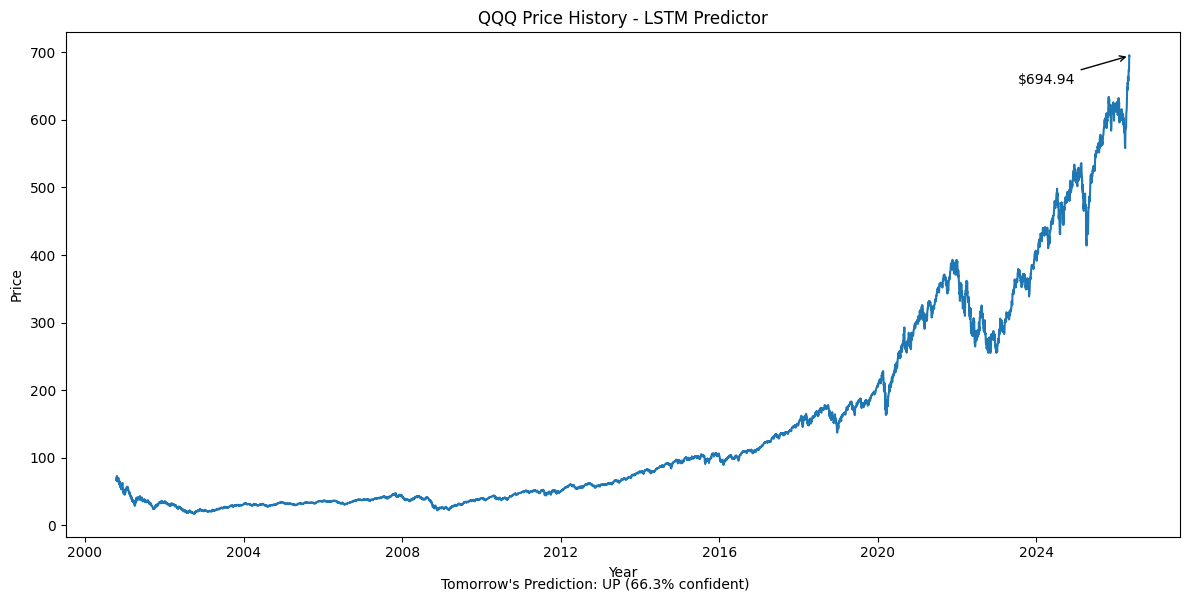

In [22]:
# Graphing
# Get last price
last_price = float(df["Close"].iloc[-1])

# Get LSTM prediction for tomorrow
model_lstm.eval()
with torch.no_grad():
    last_sequence = X_test_t[-1].unsqueeze(0)
    output = model_lstm(last_sequence)
    prediction = torch.argmax(output, dim=1).item()
    confidence = torch.softmax(output, dim=1)[0][prediction].item()

direction = "UP" if prediction == 1 else "DOWN"

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df["Close"])
plt.title("QQQ Price History - LSTM Predictor")
plt.xlabel("Year")
plt.ylabel("Price")

plt.annotate(
    f"${last_price:.2f}",
    xy=(df.index[-1], last_price),
    xytext=(-80, -20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.figtext(0.5, 0.01,
    f"Tomorrow's Prediction: {direction} ({confidence*100:.1f}% confident)",
    ha="center", fontsize=10)

plt.tight_layout()
plt.show()